# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [112]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [113]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [114]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(546, 78, 156)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


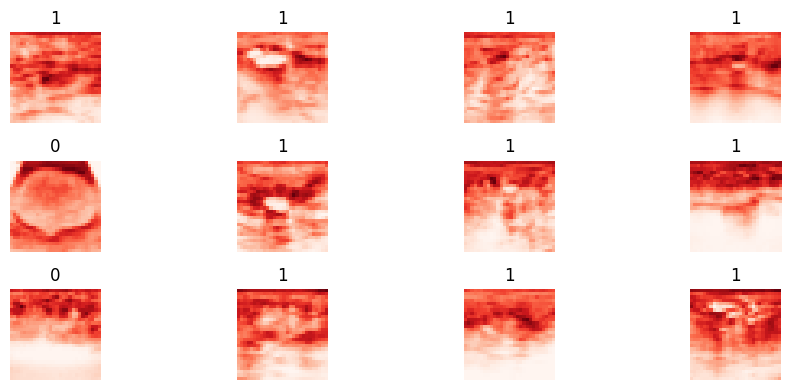

In [115]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="Reds")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [117]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [118]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [119]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = [] # <- NUEVO: Lista para guardar las pérdidas

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        # <- NUEVO: Calculamos la pérdida si se proporciona el criterion
        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    # <- NUEVO: Calculamos el promedio de la pérdida
    val_loss = np.mean(losses) if losses else 0.0

    return acc, auc, val_loss, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [120]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 20
# <- NUEVO: Agregamos "val_loss" al diccionario
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)

    # <- NUEVO: Pasamos el criterion y recibimos val_loss
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_scratch, val_loader, criterion)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss) # <- NUEVO: Guardamos val_loss
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    # Actualizamos el print para ver la pérdida de validación en tiempo real
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6648 | val_loss=0.6374 | val_acc=0.7308 | val_auc=0.5430
Epoch 02 | train_loss=0.6123 | val_loss=0.5834 | val_acc=0.7308 | val_auc=0.5439
Epoch 03 | train_loss=0.5736 | val_loss=0.6000 | val_acc=0.7308 | val_auc=0.5472
Epoch 04 | train_loss=0.5919 | val_loss=0.5845 | val_acc=0.7308 | val_auc=0.5464
Epoch 05 | train_loss=0.5564 | val_loss=0.5797 | val_acc=0.7308 | val_auc=0.5455
Epoch 06 | train_loss=0.5830 | val_loss=0.5793 | val_acc=0.7308 | val_auc=0.5480
Epoch 07 | train_loss=0.5632 | val_loss=0.5787 | val_acc=0.7308 | val_auc=0.5505
Epoch 08 | train_loss=0.5482 | val_loss=0.5809 | val_acc=0.7308 | val_auc=0.5589
Epoch 09 | train_loss=0.5623 | val_loss=0.5835 | val_acc=0.7308 | val_auc=0.5664
Epoch 10 | train_loss=0.5855 | val_loss=0.5783 | val_acc=0.7308 | val_auc=0.5714
Epoch 11 | train_loss=0.5488 | val_loss=0.5768 | val_acc=0.7308 | val_auc=0.5764
Epoch 12 | train_loss=0.5674 | val_loss=0.5769 | val_acc=0.7308 | val_auc=0.5823
Epoch 13 | train_loss=0.5746

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


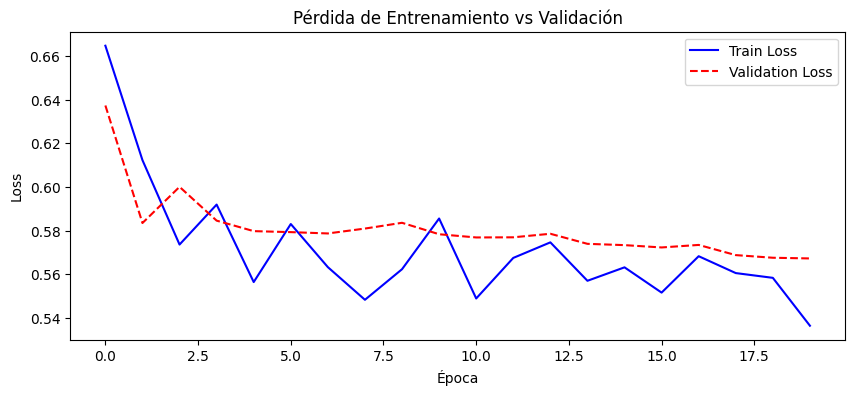

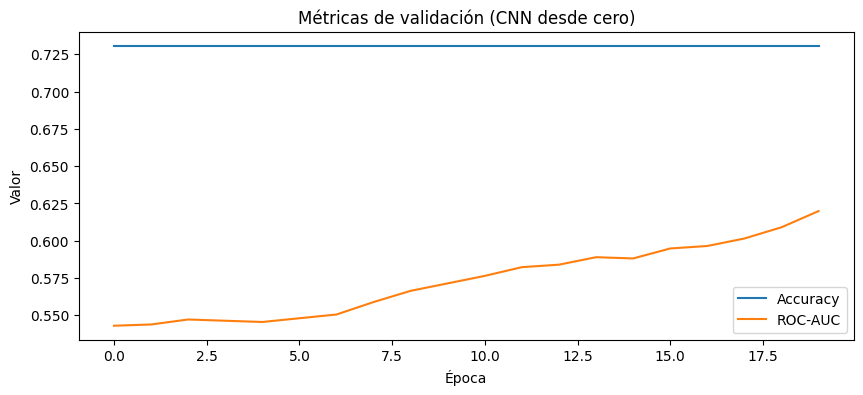

In [121]:
plt.figure(figsize=(10, 4))
# Graficamos ambas pérdidas juntas
plt.plot(history_scratch["train_loss"], label="Train Loss", color="blue")
plt.plot(history_scratch["val_loss"], label="Validation Loss", color="red", linestyle="--")
plt.title("Pérdida de Entrenamiento vs Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend() # Importante para mostrar qué color es cada curva
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [122]:
# Añadimos test_loss como la tercera variable y pasamos el criterion
test_acc, test_auc, test_loss, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader, criterion)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test Loss:     {test_loss:.4f}") # Opcional: imprimir la pérdida
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.7308
Test ROC-AUC:  0.6773
Test Loss:     0.5501

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        42
           1     0.7308    1.0000    0.8444       114

    accuracy                         0.7308       156
   macro avg     0.3654    0.5000    0.4222       156
weighted avg     0.5340    0.7308    0.6171       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[  0,  42],
       [  0, 114]])

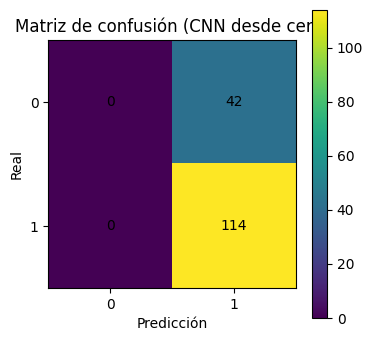

In [123]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [124]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [126]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _,_, = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.6529 | val_acc=0.7308 | val_auc=0.5480
Epoch 02 | train_loss=0.5883 | val_acc=0.7308 | val_auc=0.5439
Epoch 03 | train_loss=0.5584 | val_acc=0.7308 | val_auc=0.5414
Epoch 04 | train_loss=0.5970 | val_acc=0.7308 | val_auc=0.5414
Epoch 05 | train_loss=0.5649 | val_acc=0.7308 | val_auc=0.5464
Epoch 06 | train_loss=0.5679 | val_acc=0.7308 | val_auc=0.5447


### 6.1. Comparación rápida


In [128]:
test_acc_aug, test_auc_aug, _, _, _,_, = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.7308 | test_auc=0.6773
Con augmentation  | test_acc=0.7308 | test_auc=0.5984


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [129]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [130]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [132]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _,_, = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.6043 | val_acc=0.7308 | val_auc=0.5280
Stage1 Epoch 02 | train_loss=0.5652 | val_acc=0.7436 | val_auc=0.5505
Stage1 Epoch 03 | train_loss=0.5502 | val_acc=0.7564 | val_auc=0.6358
Stage1 Epoch 04 | train_loss=0.5337 | val_acc=0.7436 | val_auc=0.6809


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [133]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [135]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _,_, = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.3846 | val_acc=0.8462 | val_auc=0.9173
Stage2 Epoch 02 | train_loss=0.2936 | val_acc=0.8590 | val_auc=0.9474
Stage2 Epoch 03 | train_loss=0.2535 | val_acc=0.8718 | val_auc=0.9474
Stage2 Epoch 04 | train_loss=0.2011 | val_acc=0.9103 | val_auc=0.9348


### 7.3. Evaluación en test del modelo con transfer learning


In [138]:
# Agregamos el guion bajo "_" como tercer elemento
test_acc_tl, test_auc_tl, _, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)

print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8590 | test_auc=0.9154

              precision    recall  f1-score   support

           0     0.7500    0.7143    0.7317        42
           1     0.8966    0.9123    0.9043       114

    accuracy                         0.8590       156
   macro avg     0.8233    0.8133    0.8180       156
weighted avg     0.8571    0.8590    0.8579       156



array([[ 30,  12],
       [ 10, 104]])

### 7.4. Comparación global (resumen)


In [139]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.7308 | auc=0.6773
CNN desde cero (con aug)  | acc=0.7308 | auc=0.5984
Transfer learning (ResNet) | acc=0.8590 | auc=0.9154


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [140]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


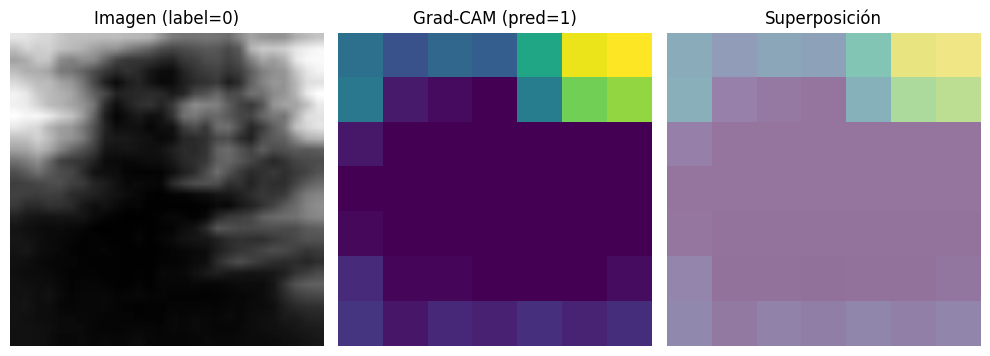

In [141]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.
